# Portfolio Optimization using QAOA

In this module, you will:
- Understand the **Quantum Approximate Optimization Algorithm (QAOA)** — a leading variational algorithm for combinatorial optimization on near-term quantum hardware.
- Learn the **mathematical formulation** of the portfolio optimization problem: how expected returns, risk (covariance), and a budget constraint are encoded into a cost Hamiltonian.
- Build and run the QAOA optimization using the QpiAI Quantum SDK — configuring the `PortfolioOptimizationProblem`, the `QAOASolver`, and interpreting the results.
- Analyze the optimization landscape, convergence behaviour, and the decoded portfolio allocation.

## What is Portfolio Optimization?

Portfolio optimization aims to:
- **Maximize** expected returns
- **Minimize** portfolio risk (variance / covariance)
- **Satisfy** a budget constraint (target total allocation)

These competing objectives are combined into a single cost function (Hamiltonian) that QAOA minimizes.

## QAOA vs VQE

| Feature | QAOA | VQE |
|:---|:---|:---|
| Circuit structure | Alternating cost + mixer layers | Generic parameterized ansatz |
| Target use case | Combinatorial / discrete optimization | General ground-state energy |
| Key parameters | $(\gamma, \beta)$ per layer | Ansatz-dependent |

QAOA typically works better for **discrete** optimization problems such as portfolio selection.

**Key Insight:** Each qubit represents one asset. A qubit in the $|1\rangle$ state means the corresponding asset is selected; $|0\rangle$ means it is not. The algorithm explores $2^n$ possible allocations in superposition and converges on the one that best satisfies all objectives.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `PortfolioOptimizationProblem` — encodes asset returns, covariance, and budget constraint into a QUBO / Ising Hamiltonian.
- `QAOASolver` — implements the QAOA variational loop: circuit construction, measurement, expectation-value computation, and classical parameter update.
- **Solver configuration:** `layers` (p parameter), `ansatz`, `optimizer`, `max_iterations`, `mixer`.
- **Execution:** `solver.run(problem, shots, experiment_name, device_name)`.
- **Results:** `result.optimal_energy`, `result.bitstring`, `result.solution`, `result.energy_history`, `result.counts`, `result.is_valid`, `result.validation_message`.

We will first review the problem setup, then configure the solver and interpret the output.

## 3. Theory: The Portfolio Hamiltonian

Given $n$ assets, we define:

- $\mu_i$ — expected return of asset $i$.
- $\Sigma_{ij}$ — covariance between assets $i$ and $j$.
- $B$ — budget (target total allocation).
- $q$ — risk tolerance parameter.

The cost function to **minimize** is:

$$C(x) = -\sum_i \mu_i\, x_i \;+\; q \sum_{i,j} \Sigma_{ij}\, x_i\, x_j \;+\; \lambda \left(\sum_i x_i - B\right)^2$$

where $x_i \in \{0, 1\}$ indicates whether asset $i$ is selected.

### Mapping to Qubits

Each binary variable $x_i$ maps to a qubit via $x_i = \frac{1 - Z_i}{2}$. This converts $C(x)$ into an Ising Hamiltonian with:

- **$Z_i$ terms** — linear contributions from returns and budget.
- **$Z_i Z_j$ terms** — pairwise interactions from the covariance matrix.
- **Constant (Identity) terms** — collected into the energy offset.

### QAOA Structure

QAOA with $p$ layers prepares the state:

$$|\gamma, \beta\rangle = \prod_{l=1}^{p} e^{-i \beta_l H_{\text{mix}}}\, e^{-i \gamma_l H_{\text{cost}}} |+\rangle^{\otimes n}$$

1. Start from the uniform superposition $|+\rangle^{\otimes n}$.
2. Apply **cost layer** $e^{-i \gamma H_{\text{cost}}}$ — encodes the optimization problem.
3. Apply **mixer layer** $e^{-i \beta H_{\text{mix}}}$ — explores the solution space.
4. Measure in the computational basis.
5. Classically optimize $(\gamma, \beta)$ to minimize $\langle H_{\text{cost}} \rangle$.

## 4. Define Portfolio Optimization Problem

We construct a portfolio problem with **4 assets**, each represented by one qubit:

| Asset | Expected Return | Variance |
|:---:|:---:|:---:|
| 0 | 5 % | 1 % |
| 1 | 10 % | 2 % |
| 2 | 15 % | 3 % |
| 3 | 8 % | 1.5 % |

Off-diagonal entries in the covariance matrix capture correlations between assets.

We target a budget of **2.0 units** and a risk tolerance of **1.0**.

In [2]:
from qpiai_quantum.algorithms.opt.solvers import QAOASolver
from qpiai_quantum.algorithms.opt.problems import PortfolioOptimizationProblem
import numpy as np

# Expected returns for 4 assets
returns = np.array([0.05, 0.10, 0.15, 0.08])

# Covariance (risk) matrix — symmetric, positive-semidefinite
risk_matrix = np.array([
    [0.010, 0.001, 0.002, 0.0015],  # Asset 0
    [0.001, 0.020, 0.003, 0.0020],  # Asset 1
    [0.002, 0.003, 0.030, 0.0025],  # Asset 2
    [0.0015, 0.0020, 0.0025, 0.015] # Asset 3
])

# Create portfolio problem
portfolio = PortfolioOptimizationProblem(
    returns=returns,
    risk_matrix=risk_matrix,
    budget=2.0,
    risk_tolerance=1.0
)

print(f"Problem: Portfolio Optimization using QAOA")
print(f"Assets: {len(returns)}")
print(f"Budget: {portfolio.budget}")
print(f"n_qubits: {portfolio.n_qubits}")
print(f"\nExpected Returns: {returns}")
print(f"Risk Matrix diagonal (variances): {np.diag(risk_matrix)}")

Problem: Portfolio Optimization using QAOA
Assets: 4
Budget: 2.0
n_qubits: 4

Expected Returns: [0.05 0.1  0.15 0.08]
Risk Matrix diagonal (variances): [0.01  0.02  0.03  0.015]


## 5. Examine the Hamiltonian

The SDK converts the portfolio parameters into Pauli Hamiltonian terms automatically.

Let's inspect the first several terms to see the structure:
- **$Z_i$ terms** — linear (return + budget penalty)
- **$Z_i Z_j$ terms** — pairwise (covariance + budget penalty)
- **Identity terms** — energy constants

In [3]:
terms = portfolio.get_hamiltonian_terms()
print(f"\nTotal Hamiltonian terms: {len(terms)}")
print(f"\nFirst 15 terms:")
for i, (ops, coeff) in enumerate(terms[:15]):
    if ops:
        op_str = ' '.join([f"{op}_{qi}" for qi, op in ops])
    else:
        op_str = "Identity (constant)"
    print(f"  Term {i:2d}: {op_str:35s} coeff={coeff:9.5f}")


Total Hamiltonian terms: 75

First 15 terms:
  Term  0: Z_0                                 coeff=  0.02500
  Term  1: Identity (constant)                 coeff= -0.02500
  Term  2: Z_1                                 coeff=  0.05000
  Term  3: Identity (constant)                 coeff= -0.05000
  Term  4: Z_2                                 coeff=  0.07500
  Term  5: Identity (constant)                 coeff= -0.07500
  Term  6: Z_3                                 coeff=  0.04000
  Term  7: Identity (constant)                 coeff= -0.04000
  Term  8: Z_0                                 coeff= -0.00250
  Term  9: Identity (constant)                 coeff=  0.00250
  Term 10: Z_0 Z_1                             coeff=  0.00025
  Term 11: Z_0                                 coeff= -0.00025
  Term 12: Z_1                                 coeff= -0.00025
  Term 13: Identity (constant)                 coeff=  0.00025
  Term 14: Z_0 Z_2                             coeff=  0.00050


## 6. Configure QAOA Solver

We create a `QAOASolver` with the following settings:

| Parameter | Value | Description |
|:---|:---|:---|
| `layers` | 1 | Number of QAOA layers ($p$ parameter). More layers ≈ better approximation ratio |
| `ansatz` | `'standard'` | Standard QAOA circuit (cost + mixer layers) |
| `optimizer` | `'spsa'` | SPSA optimizer — gradient-free, well suited for noisy landscapes |
| `max_iterations` | 5 | Number of classical optimization iterations |
| `mixer` | `'x'` | X-mixer (standard transverse-field mixer) |

Each QAOA layer has two parameters:
- $\gamma$ — cost-layer angle
- $\beta$ — mixer-layer angle

So with $p = 1$ the optimizer tunes 2 scalar parameters (plus any Hamiltonian-derived angles).

In [9]:
solver = QAOASolver(
    problem=portfolio,
    layers=1,                    # Number of QAOA layers (p parameter)
    ansatz='standard',           # Standard QAOA circuit
    optimizer='spsa',            # SPSA optimizer
    max_iterations=10,            # Optimization iterations
    mixer='x'                    # X-mixer (standard choice)
)

print(f"\nQAOA Configuration:")
print(f"  Layers: {solver.layers}")
print(f"  Ansatz: {solver.ansatz}")
print(f"  Optimizer: {solver.optimizer}")
print(f"  Max Iterations: {solver.max_iterations}")
print(f"  Mixer: {solver.mixer}")
print(f"\nNote: QAOA with p={solver.layers} layers uses {2*solver.layers} parameters (gamma, beta per layer)")


QAOA Configuration:
  Layers: 1
  Ansatz: standard
  Optimizer: SPSA
  Max Iterations: 10
  Mixer: x

Note: QAOA with p=1 layers uses 2 parameters (gamma, beta per layer)


## 7. Run QAOA Optimization

We now execute the QAOA algorithm on QpiAI's quantum simulator.

The algorithm will:
1. Initialize parameters $(\gamma, \beta)$ for each layer.
2. Build the QAOA circuit with these parameters.
3. Execute the circuit and measure results.
4. Compute the expectation value of the cost Hamiltonian.
5. Update parameters using the SPSA optimizer.
6. Repeat until convergence or `max_iterations`.

> **Simulator default:** `device_name='QpiAI-QSV-Local'`. To run on a QPU, change to `device_name='QpiAI-Indus-1'` and configure an experiment with the same name in the QpiAI web UI.

This may take a few minutes depending on the number of iterations.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [10]:
# Note: experiment_name is only required for cloud executions
result = solver.run(
    shots=10000,
    device_name='QpiAI-QSV-Local'
)

print(f"\n" + "="*70)
print("QAOA RESULTS SUMMARY")
print("="*70)
print(f"Optimal energy: {result.optimal_energy:.6f}")
print(f"Best bitstring: {result.bitstring}")
print(f"Iterations: {result.metadata['actual_iterations']}")
print(f"Circuit Evaluations: {result.metadata['circuit_evaluations']}")
print(f"Success: {result.metadata['success']}")
print(f"Converged early: {result.metadata['converged_early']}")


QAOA OPTIMIZATION STARTING
Optimizer:        SPSA
Parameters:       58
QAOA Layers:      1
Max Iterations:   10
Shots per eval:   10000
Expected Evals:   ~31 (may stop early if converged)
  |-- 1 initial + 10 iterations x 3 evals/iter

Note: Optimizer may stop earlier if convergence criteria are met.


QAOA OPTIMIZATION COMPLETED
Actual Iterations:   10
Max Iterations:      10
Circuit Evaluations: 31
Final Energy:        -0.515386
Success:             True

 Note: Optimizer reached max_iterations limit


QAOA RESULTS SUMMARY
Optimal energy: -0.515386
Best bitstring: 0001
Iterations: 10
Circuit Evaluations: 31
Success: True
Converged early: False


## 8. Decode and Validate Solution

The solver returns a bitstring encoding the portfolio allocation. Let's decode it and validate that the budget constraint is satisfied:

In [11]:
print(f"\n" + "="*70)
print("PORTFOLIO ALLOCATION")
print("="*70)

solution = result.solution
allocation = solution['allocation']
selected_assets = solution['selected_assets']

print(f"\nAllocation vector: {allocation}")
print(f"Total allocation: {np.sum(allocation):.4f} (target: {portfolio.budget})")
print(f"\nSelected assets: {selected_assets}")
print(f"Number of assets: {len(selected_assets)}")

is_valid = result.is_valid
validation_message = result.validation_message

print(f"\nValidation: {validation_message}")
print(f"Is valid: {is_valid}")

print(f"\nDetailed Allocation:")
for i, (alloc, ret) in enumerate(zip(allocation, returns)):
    status = "✅ SELECTED" if i in selected_assets else "   not selected"
    print(f"  Asset {i}: {alloc:.4f} units (expected return: {ret:.1%})  {status}")


PORTFOLIO ALLOCATION

Allocation vector: [2. 0. 0. 0.]
Total allocation: 2.0000 (target: 2.0)

Selected assets: [0]
Number of assets: 1

Validation: Valid portfolio allocation
Is valid: True

Detailed Allocation:
  Asset 0: 2.0000 units (expected return: 5.0%)  ✅ SELECTED
  Asset 1: 0.0000 units (expected return: 10.0%)     not selected
  Asset 2: 0.0000 units (expected return: 15.0%)     not selected
  Asset 3: 0.0000 units (expected return: 8.0%)     not selected


## 9. Visualize Optimization Progress

Let's plot the energy convergence during QAOA optimization and the measurement distribution:

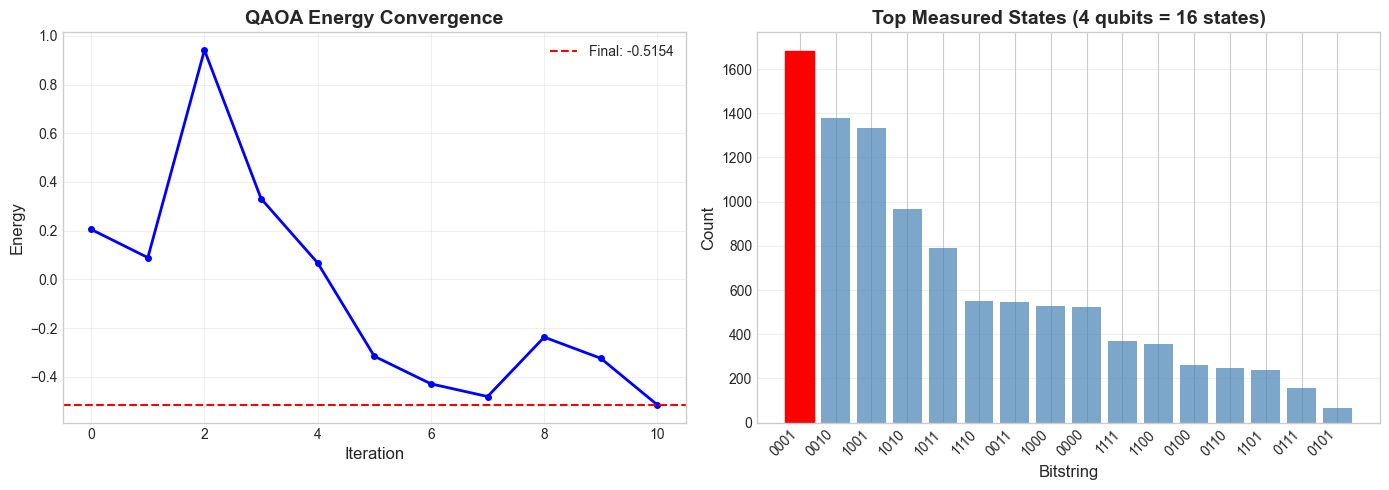


Optimal bitstring (in red): 0001
Measured 1682 times out of 10000 shots
Probability: 16.82%


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Energy convergence ──
ax = axes[0]
energy_history = result.energy_history
ax.plot(energy_history, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=result.optimal_energy, color='r', linestyle='--', label=f'Final: {result.optimal_energy:.4f}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('QAOA Energy Convergence', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# ── Measurement histogram ──
ax = axes[1]
counts = result.counts
if counts:
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:16]
    bitstrings = [item[0] for item in sorted_counts]
    values = [item[1] for item in sorted_counts]
    
    bars = ax.bar(range(len(bitstrings)), values, color='steelblue', alpha=0.7)
    if result.bitstring in bitstrings:
        optimal_idx = bitstrings.index(result.bitstring)
        bars[optimal_idx].set_color('red')
        bars[optimal_idx].set_alpha(1.0)
    
    ax.set_xlabel('Bitstring', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Top Measured States (4 qubits = 16 states)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(bitstrings)))
    ax.set_xticklabels(bitstrings, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nOptimal bitstring (in red): {result.bitstring}")
if counts and result.bitstring in counts:
    print(f"Measured {counts[result.bitstring]} times out of {sum(counts.values())} shots")
    print(f"Probability: {counts[result.bitstring]/sum(counts.values()):.2%}")

### Results Interpretation

**Reading the bitstring:**
- Each bit corresponds to an asset (bit 0 → Asset 0, bit 1 → Asset 1, etc.).
- `1` means the asset is selected; `0` means it is not.
- For example, bitstring `0110` means Assets 1 and 2 are selected.

**Validation:**
- A valid allocation satisfies the budget constraint: $\sum_i x_i = B$.
- The `is_valid` flag and `validation_message` confirm this automatically.

**Energy:**
- Lower energy = better trade-off between return maximization, risk minimization, and budget adherence.
- The energy convergence plot shows how the optimizer refines $(\gamma, \beta)$ across iterations.

**On a noisy QPU:** The optimal bitstring should still dominate the histogram, but noise introduces contributions from sub-optimal states.

## 10. Exercises

**Beginner:**

1. Change the budget to **3.0** and re-run. How does the selected portfolio change?
2. Double the expected return of Asset 3 to 16 %. Does QAOA now select it?

**Intermediate:**

3. Increase `layers` to 2 or 3 and compare the convergence behaviour and final energy. How many more circuit evaluations are needed?
4. Switch the optimizer from `'spsa'` to `'cobyla'` and compare results. Which converges faster for this 4-asset problem?

**Advanced:**

5. Add a 5th asset and expand the covariance matrix. How does the solution space grow ($2^5 = 32$ states)? Run with increasing `max_iterations` and report convergence.
6. QAOA is closely related to adiabatic quantum computing. Research the **Quantum Adiabatic Theorem** and explain why deeper QAOA circuits (larger $p$) should, in principle, yield better approximation ratios.

## 11. Key Takeaways

- **QAOA** solves combinatorial optimization problems by encoding the objective as a quantum Hamiltonian and variationally minimizing its expectation value.
- The **portfolio optimization** Hamiltonian encodes return maximization, risk minimization, and a budget constraint.
- With 4 assets, the search space has $2^4 = 16$ possible allocations — small enough to verify classically, but the same algorithm scales to much larger instances on quantum hardware.
- The QpiAI SDK provides `PortfolioOptimizationProblem` for automatic Hamiltonian construction and `QAOASolver` for the full variational loop.
- QAOA with $p$ layers uses $2p$ parameters $(\gamma_1, \beta_1, \dots, \gamma_p, \beta_p)$. More layers generally improve solution quality at the cost of deeper circuits and more evaluations.
- On a **statevector simulator**, results are noiseless. On real hardware, noise may degrade the optimal bitstring probability.

---
**Thank you for learning with QpiAI!**

In [13]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.40
